In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, LearningCurveDisplay
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier

# Load the dataset

In [ ]:
data = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Molecules_Toxicity_Classification.xlsx")

#Data Exploration

In [ ]:
data.shape

(159, 1205)

## Check datatypes to get an idea about encodings

In [ ]:
data.dtypes

,0
Unnamed: 0,int64
MATS3v,float64
nHBint10,int64
MATS3s,float64
MATS3p,float64
...,...
nT5Ring,int64
SHdNH,float64
ETA_dEpsilon_C,float64
MDEO-22,float64


Since the data is an excel file, the first column is just the number of the example, so it is unnecessary.

On a side note, when we accidentally trained with this column, the accuracy was very high, meaning the model was relating the numbers of the examples to the class, indicating that the data may have been ordered by class, meaning we need to shuffle later.

In [ ]:
data.drop("Unnamed: 0", inplace=True, axis=1)

## Feature and Target Encoding

All features were numerical variables, therefore no encoding was needed.
For the target variable, we used Label Encoding since it is just a binary classification task.

In [ ]:
encoder = LabelEncoder()
data["Class"] = encoder.fit_transform(data["Class"])

data.dtypes

,0
MATS3v,float64
nHBint10,int64
MATS3s,float64
MATS3p,float64
nHBDon_Lipinski,int64
...,...
nT5Ring,int64
SHdNH,float64
ETA_dEpsilon_C,float64
MDEO-22,float64


# Data Visualization

The data is clearly imbalanced, which tells us that we need to find ways to deal with it later.

Our data is very scarce, so undersampling is not an option, therefore, we will most likely have to go with an oversampling technique.

<Axes: xlabel='Class', ylabel='count'>

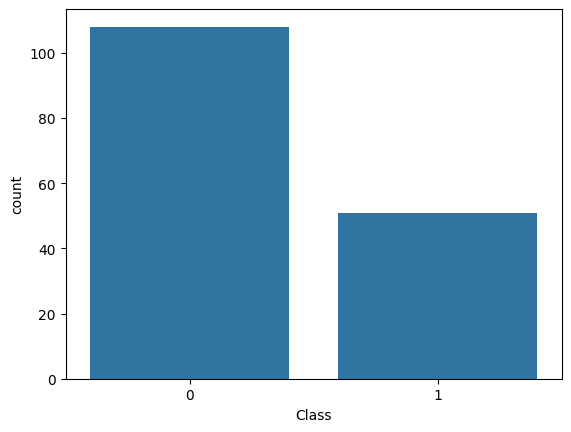

In [ ]:
sns.countplot(data, x="Class")

Seperate target from features

In [ ]:
X = data.drop("Class", axis=1)
y = data["Class"]

## Train-Test split

Again, since our data is very scarce, we decided to go with a 7% test split.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size = 0.07, shuffle=True, random_state=42)

# Pipeline, General Workflow

## Scaling
> We scaled the features using z-scale normalization in order to ensure similar ranges for features and quick convergence of gradient descent

## SMOTE oversampling
> For oversampling, we decided to go with SMOTE. We acknowledge that SMOTE might produce molecules with wrong classes, however, we prefered it to random oversampling since because the data is very limited, we need more examples to help combat overfitting. Random oversampling would help with biased class representation, but would maybe cause more overfitting since we are using the same examples

## Feature Selection
> Due to the extreme number of features of 1203, we decided to perform feature selection. We used SelectKBest since it keeps the features intact, and actually measures their corrolation to the target. This is in contrast to PCA, which is more of a dimensionality reduction algorithm, which doesnt maintain the features, and only measures variance independent of the target.

## Cross Validation
> In order to perform model selection, we decided to go with a 10-split Stratified K-fold cross validation. We realize that the classes are already balanced due to SMOTE, however we set stratify=True for safety. We used a 10-split to ensure maximum training data.

## Grid Search for Hyperparameter Tuning
> In order to choose the best hyperparameters for our model while avoiding data leakage from our test set, we used sklearn's GridSearch, which varies hyperparameters automatically then tests the model on them. In the end, we select the best_estimator from the GridSearch, and test it on the testing set.

## Performance Metrics
> Since our dataset is unbalanced, we made sure to test with multiple measures which are Accuracy, F1, Precision, Recall, and ROC AUC. In the GridSearch, we optimized for ROCAUC.

## Baseline
> In order to establish a baseline, we looked up the dataset, and found it on UCIrvine's website. Alongside it was a study that trained multiple models on this dataset. Although the aim of the study was feature selection, more so than it was accuracy, we still used their accuracy of 78% achieved with a DT as a baseline for our models.

# Logistic Regression

> The first modelewe trained was a simple Logistic Regression.
> We Used L1 regularization to perform automatic feature selection in order to reduce the number of features further. We made sure to vary the regularization parameter in order to find the best on in GridSearch.
> This established a baseline for comparing to the study, as well as to compare to our other models

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    # ('oversampling', RandomOverSampler(random_state=0)),
    ('SMOTE_overampling', SMOTE(sampling_strategy="minority", k_neighbors=5, random_state=0)),
    ('feature_selection', SelectKBest(score_func=f_classif, k=300)),
    ('classifier', LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", max_iter=1000, random_state=0))
])

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

In [ ]:
params = {
    "feature_selection__k":np.arange(10, 50, 10),
    "classifier__C":[1, 10],
}

In [ ]:
grid_search = GridSearchCV(pipeline, params, scoring="roc_auc", cv=cv)

In [ ]:
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 96 186 733 853 949] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 197  522  939 1121 1175] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  69  203  214  253  301  327  378  564  702  724  759  792  989 1028
 1035 

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('SMOTE_overampling',
                                        SMOTE(random_state=0,
                                              sampling_strategy='minority')),
                                       ('feature_selection',
                                        SelectKBest(k=300)),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           penalty='l1',
                                                           random_state=0,
                                                           solver='liblinear'))]),
             param_grid={'classifier__C': [1, 10],
                         'feature_selection__k': array([10, 20, 30, 40])},
             scoring='roc_auc')

In [ ]:
grid_search.best_score_

np.float64(0.46349999999999997)

In [ ]:
grid_search.best_params_

{'classifier__C': 10, 'feature_selection__k': np.int64(10)}

In [ ]:
lr = grid_search.best_estimator_

In [ ]:
y_pred = lr.predict(X_test)

## Threshold adjustment
> The model was giving a lot of false positives on both training and testing data, so we increased the threshold

In [ ]:
y_pred = (lr.predict_proba(X_test)[:,1] >= 0.55).astype(int)

## High accuracy
> This model seemed to achieve high accuracy on our test set. However, we didn't trust this result beacuse of 2 reasons:

> 1. Our test set is very small
> 2. The data seemed to complex for it to be captured in a basic linear relationship.

In [ ]:
accuracy_score(y_test, y_pred)

0.8333333333333334

In [ ]:
f1_score(y_test, y_pred)

0.75

In [ ]:
recall_score(y_test, y_pred)

0.75

In [ ]:
precision_score(y_test, y_pred)

0.75

## Checking training metrics

> In order to test our suspicions, we evaluated the training accuarcy of the model.
> This accuracy was low, indicating that the model was indeed underfitting.

In [ ]:
accuracy_score(y_train, lr.predict(X_train))

0.6258503401360545

## Learning curves visualization

> The learning curves clearly showed that the model was not learning properly.

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py", line 518, in fit
    Xt, yt = self._fit(X, y, routed_param

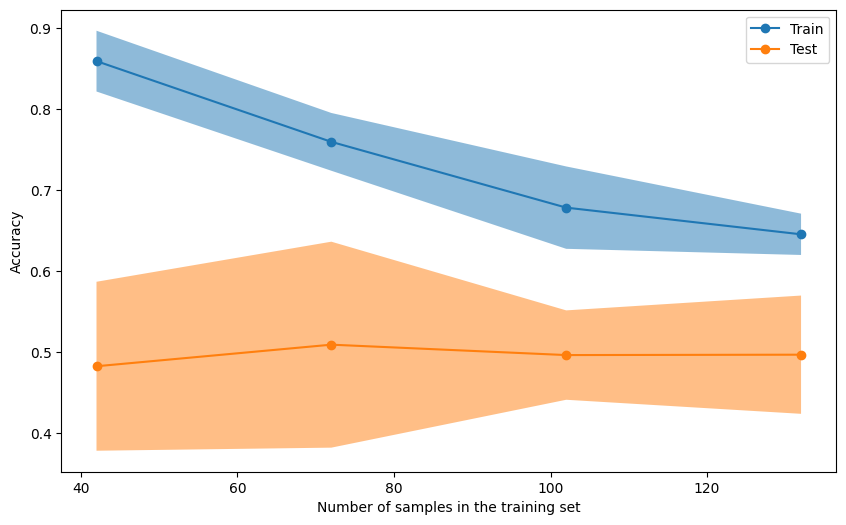

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))

common_params = {
    "X": X_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": cv,
    "score_type": "both",
    "n_jobs": 4,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "Accuracy",
}

LearningCurveDisplay.from_estimator(lr, **common_params, ax=ax)

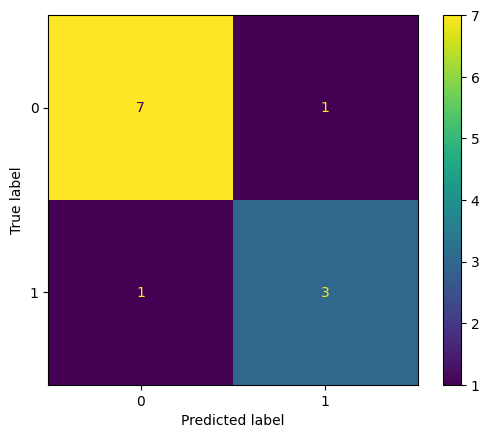

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
plt.show()

# Random Forest Classifier

> The next model we trained is a Random Forest Classifier. With this model, we hoped to capture non-linear relationships in order to get better results. Using Ensemble methods also helps prevent overfitting.

In [ ]:
RF_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    # ('oversampling', RandomOverSampler(random_state=0)),
    ('SMOTE_overampling', SMOTE(sampling_strategy="minority", k_neighbors=5, random_state=5)),
    ('feature_selection', SelectKBest(score_func=f_classif, k=300)),
    ('classifier', RandomForestClassifier(max_depth=5, n_estimators=100, class_weight="balanced", random_state=0, min_samples_split=2, min_samples_leaf=3, max_features="sqrt"))
])

In [ ]:
RF_params = {
    "feature_selection__k":np.arange(100, 401, 100),
    "classifier__max_depth":np.arange(1, 21, 5),
    "classifier__n_estimators":[100, 200],
}

In [ ]:
RF_grid_search = GridSearchCV(RF_pipeline, RF_params, scoring="roc_auc", cv=cv)

In [ ]:
RF_grid_search.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 96 186 733 853 949] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 197  522  939 1121 1175] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  69  203  214  253  301  327  378  564  702  724  759  792  989 1028
 1035 

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('SMOTE_overampling',
                                        SMOTE(random_state=5,
                                              sampling_strategy='minority')),
                                       ('feature_selection',
                                        SelectKBest(k=300)),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               max_depth=5,
                                                               min_samples_leaf=3,
                                                               random_state=0))]),
             param_grid={'classifier__max_depth': array([ 1,  6, 11, 16]),
                         'classifier__n_estimators': [100, 200],
                         'feature_selection__k': array([100, 200, 300, 400])},
             scoring='roc_auc')

In [ ]:
RF_grid_search.best_score_

np.float64(0.5615000000000001)

In [ ]:
RF_grid_search.best_params_

{'classifier__max_depth': np.int64(6),
 'classifier__n_estimators': 100,
 'feature_selection__k': np.int64(200)}

In [ ]:
rf = RF_grid_search.best_estimator_

In [ ]:
rf_y_pred = rf.predict(X_test)

In [ ]:
rf_y_pred = (rf.predict_proba(X_test)[:,1] >= 0.6).astype(int)

## Relatively high Metrics
> This model achieved a relatively high accuracy of 75% along with a good f1 score of 66%


In [ ]:
accuracy_score(y_test, rf_y_pred)

0.75

In [ ]:
f1_score(y_test, rf_y_pred)

0.6666666666666666

In [ ]:
recall_score(y_test, rf_y_pred)

0.75

In [ ]:
precision_score(y_test, rf_y_pred)

0.6

## Assessing Overfitting

> We measured the training accuarcy and found it to be considerably higher than our testing accuracy, indicating that our model was overfitting

In [ ]:
accuracy_score(y_train, rf.predict(X_train))

0.9727891156462585

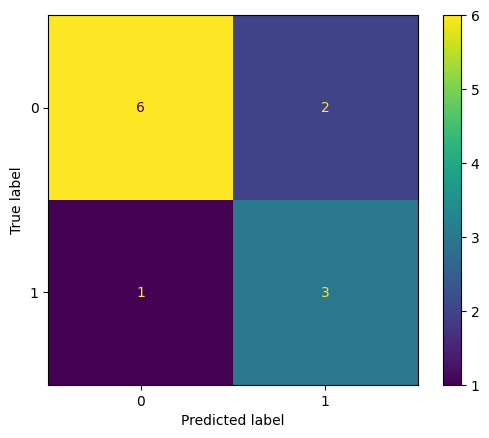

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, rf_y_pred))
disp.plot()
plt.show()

## Confirming Overfitting

> The learning curves confirmed the suspicion of overfitting.

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py", line 518, in fit
    Xt, yt = self._fit(X, y, routed_param

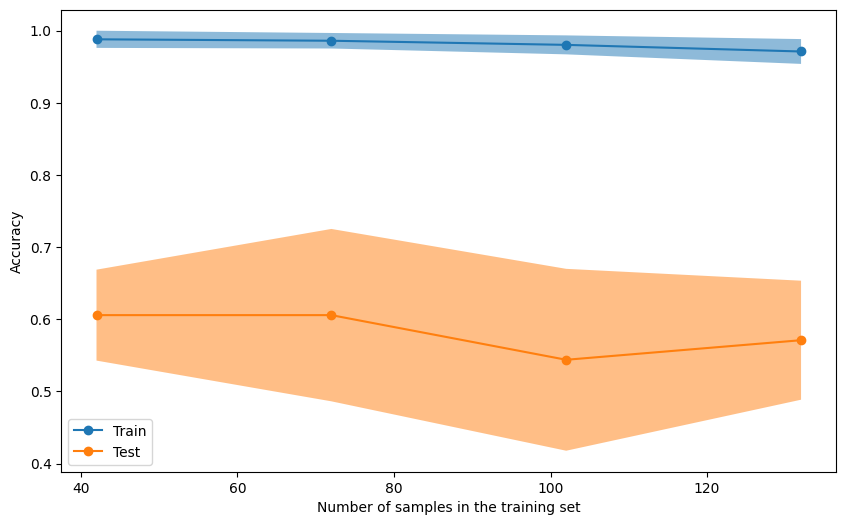

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))

common_params = {
    "X": X_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": cv,
    "score_type": "both",
    "n_jobs": 4,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "Accuracy",
}

LearningCurveDisplay.from_estimator(rf, **common_params, ax=ax)

# Decision Tree Models

> We decided to try out a Decision Tree model since that was the most successful model in the study.

In [ ]:
DT_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    # ('oversampling', RandomOverSampler(random_state=0)),
    ('SMOTE_overampling', SMOTE(sampling_strategy="minority", k_neighbors=5, random_state=5)),
    # ('feature_selection', SelectKBest(score_func=f_classif, k=300)),
    ('classifier', DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=0, min_samples_split=5, min_samples_leaf=5, max_features=None))
])

In [ ]:
DT_params = {
    "classifier__max_depth":[None],
    "classifier__min_samples_split":[5],
    "classifier__min_samples_leaf":[1],
    "classifier__max_features":[13]
}

In [ ]:
DT_grid_search = GridSearchCV(DT_pipeline, DT_params, scoring="roc_auc", cv=cv)

In [ ]:
DT_grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('SMOTE_overampling',
                                        SMOTE(random_state=5,
                                              sampling_strategy='minority')),
                                       ('classifier',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               max_depth=5,
                                                               min_samples_leaf=5,
                                                               min_samples_split=5,
                                                               random_state=0))]),
             param_grid={'classifier__max_depth': [None],
                         'classifier__max_features': [13],
                         'classifier__min_samples_leaf': [1],
                         'classifier__min_samples_split': [5]},
             scoring='roc_auc')

In [ ]:
DT_grid_search.best_score_

np.float64(0.5945000000000001)

In [ ]:
dt = DT_grid_search.best_estimator_

In [ ]:
dt_y_pred = dt.predict(X_test)

## Not great results

> The results we optained were not great, with a low accuracy and precision score

In [ ]:
accuracy_score(y_test, dt_y_pred)

0.6666666666666666

In [ ]:
f1_score(y_test, dt_y_pred)

0.6

In [ ]:
recall_score(y_test, dt_y_pred)

0.75

In [ ]:
precision_score(y_test, dt_y_pred)

0.5

## Also Overfitting

> We also felt that the model was overfitting since even ensemble methods were struggling, so again, we confirmed this by checking our training accuracy, which was also high

In [ ]:
accuracy_score(y_train, dt.predict(X_train))

0.9591836734693877

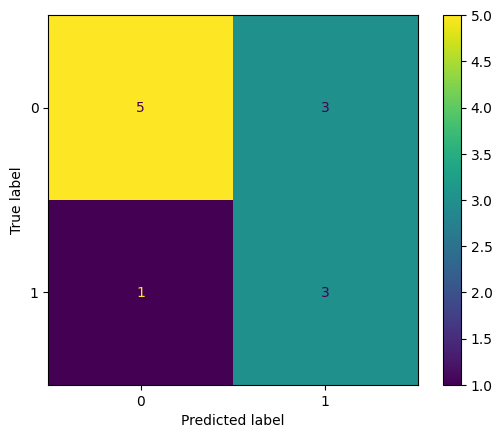

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_test, dt_y_pred)).plot()

# XGB Classifier

> We decided to use Boosting in order to try capturing more of the relationships in the data.
> We made sure to keep the depth and the number of features relatively low in order to avoid overfitting as much as possible

In [ ]:
from xgboost import XGBClassifier

In [ ]:
XG_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    # ('oversampling', RandomOverSampler(random_state=0)),
    ('SMOTE_overampling', SMOTE(sampling_strategy="minority", k_neighbors=5, random_state=5)),
    ('feature_selection', SelectKBest(score_func=f_classif, k=300)),
    ('classifier', XGBClassifier(random_state=0))
])

In [ ]:
XG_params = {
    "feature_selection__k":[20, 50, 100],
    "classifier__learning_rate":[0.1, 0.2, 0.3],
    "classifier__max_depth":np.arange(10, 31, 10),
    "classifier__gamma":[1, 5]
}

In [ ]:
XG_grid_search = GridSearchCV(XG_pipeline, XG_params, scoring="roc_auc", cv=cv)

In [ ]:
XG_grid_search.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 96 186 733 853 949] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 197  522  939 1121 1175] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  69  203  214  253  301  327  378  564  702  724  759  792  989 1028
 1035 

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('SMOTE_overampling',
                                        SMOTE(random_state=5,
                                              sampling_strategy='minority')),
                                       ('feature_selection',
                                        SelectKBest(k=300)),
                                       ('classifier',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_byno...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      random_state=0, ...))]),
             param_grid={'classifier__gamma': [1, 5],
                         'classifier__learning_rate': [0.1, 0.2, 0.3],
                         'classifier__max_depth': array([10, 20, 30]),
                         'feature_selection__k': [20, 50, 100]},
             scoring='roc_auc')

In [ ]:
XG_grid_search.best_score_

np.float64(0.53175)

In [ ]:
XG_grid_search.best_params_

{'classifier__gamma': 5,
 'classifier__learning_rate': 0.3,
 'classifier__max_depth': np.int64(10),
 'feature_selection__k': 20}

In [ ]:
xg = XG_grid_search.best_estimator_

In [ ]:
xg_y_pred = xg.predict(X_test)

## Good result

> We got a good accuracy of 75%, and a good f1 score of 66% as well.

In [ ]:
accuracy_score(y_test, xg_y_pred)

0.75

In [ ]:
f1_score(y_test, xg_y_pred)

0.7272727272727273

In [ ]:
recall_score(y_test, xg_y_pred)

1.0

In [ ]:
precision_score(y_test, xg_y_pred)

0.5714285714285714

## Checking overfitting

> We checked our training accuracy to confirm that our model was not overfitting.
> Our training accuarcy was close to our testing accuracy, which tells us that the model has a good bias-variance tradeoff

In [ ]:
accuracy_score(y_train, xg.predict(X_train))

0.8095238095238095

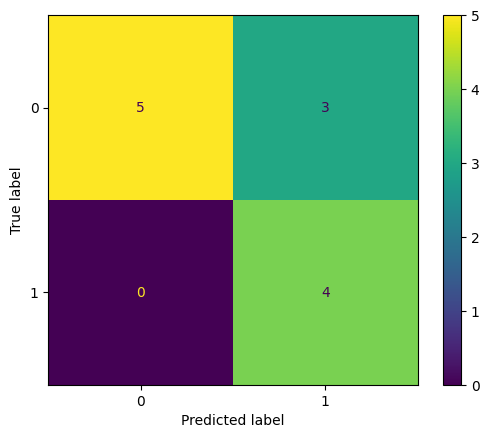

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_test, xg_y_pred)).plot()

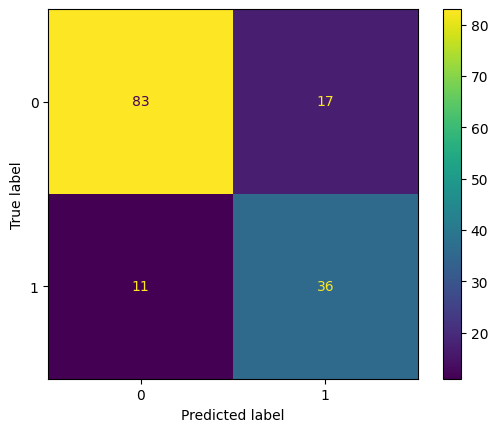

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_train, xg.predict(X_train))).plot()

## Trying to visualize the data

> In this step, we aim to make the decision between random oversampling and SMOTE oversampling. The main reason behind takind such a step is to ensure that SMOTE oversampling doesn't wrongly label data
> We will use PCA and t-SNE to maintain the distances between different classes to ensure an accurate visualization.

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100, random_state=0)
PCA_X = pca.fit_transform(X)

In [ ]:
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2, perplexity=20, early_exaggeration=10, learning_rate=20).fit_transform(PCA_X)

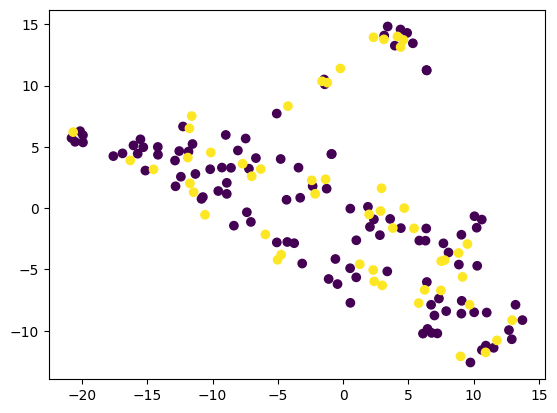

In [ ]:
fix, ax = plt.subplots(1, 1)
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y)

## SMOTE underperforming

> The plot clearly shows that the 2 classes are very entangled, meaning that SMOTE will very likely mislabel the generated points.
> This tells us that we should use oversampling instead